In [1]:

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

C:\Users\DELL\AppData\Local\Temp\ipykernel_21552\2884273280.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
load_dotenv()

True

In [3]:

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)

In [5]:
loader = PyPDFLoader("research-paper.pdf")
docs = loader.load()

In [6]:

docs

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'research-paper.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGoogle Brain\nlu

In [7]:
len(docs)

15

In [8]:

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [9]:
len(chunks)

52

In [10]:

embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)
vector_store = FAISS.from_documents(chunks, embeddings)
vector_store.save_local("faiss_index")

In [11]:

vector_store

In [12]:

retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [13]:

ans = retriever.invoke("What is attention?")
ans

[Document(id='b4f2443b-91c9-41bd-8a9c-5719dd205c93', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'research-paper.pdf', 'total_pages': 15, 'page': 2, 'page_label': '3'}, page_content='3.2 Attention\nAn attention function can be described as mapping a query and a set of key-value pairs to an output,\nwhere the query, keys, values, and output are all vectors. The output is computed as a weighted sum\n3'),
 Document(id='73b19a61-5a5d-47c0-8dac-e2412754a7ba', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Ver

In [14]:
@tool
def rag_tool(query: str) -> str:
    """
    Retrieve relevant information from the PDF document.

    Use this tool when the user asks factual or conceptual questions
    that may be answered using the stored PDF documents.

    Args:
        query: The question or search query used to retrieve PDF content.
    """

    documents = retriever.invoke(query)

    if not documents:
        return "No relevant information was found in the PDF."

    formatted_documents = []

    for index, document in enumerate(documents, start=1):
        source = document.metadata.get("source", "Unknown source")
        page = document.metadata.get("page", "Unknown page")

        formatted_documents.append(
            f"Document {index}\n"
            f"Source: {source}\n"
            f"Page: {page}\n"
            f"Content: {document.page_content}"
        )

    return "\n\n".join(formatted_documents)

In [15]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [16]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [17]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

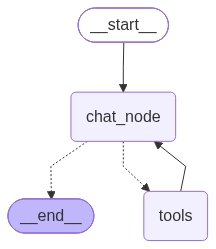

In [18]:

# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")  
chatbot = graph.compile()

chatbot

In [19]:

# Regular chat
result = chatbot.invoke({"messages": [HumanMessage(content="Hello")]})

print(result["messages"][-1].content)

Hello! I'm here to answer your questions from the PDF document. What would you like to know?


In [20]:

# Regular chat
result = chatbot.invoke({"messages": [HumanMessage(content="Using the pdf notes, explain about Rainfall Measurement techniques in a concise way")]})

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I am sorry, but the provided PDF notes do not contain information about Rainfall Measurement techniques. The content retrieved is related to machine learning, neural networks, and optimizers.', 'extras': {'signature': 'Co8DARFNMg9oWzTFvsYlR+Qn8khNw7wyrGTNEn4dtT61f20mHpqidG1vmP49UjRLp8mbjrPDatbXSgLDoTqe5j8eTEvVTeXgyRGt/BWpeK/IpOEdQXt1g70TsNnTvgxNIgUSKVtLT9c+NFFzPK91jcEy66mP+R2YG5U2VIskNUnS+FS/ZwjE2YG/IHog8fEcujQcQFQ385IEIzFY5nxU7UQ9Pyzdiju8YsBzwt3S3vzTWSEjcBlHXVeD5A6cfR9RE/hv+0DTYP597AeJrhO7kN8/u3ssuASYoHEeYCGfuHq8laPhy/eyydWE7d7nDlNpeNVmUszNmODJOUEatoXNS1VXkkHnslEud7dh90fuAWyaE1PG7+zygLReBRAphFbZXTRvRbt4DNwwfGYjw9pwURvgaNMNulsJqhZ+g3hZhyjp6vkcV0hapbrqkEbCeBRGSXRkmH4VUEYP63kVD9YGupBQZiXjg3u76IhDHCCEXHhpmj5ENmigspmn1Le9BVyqqV/ifx2d10TrbzR6Lcfl7F//'}}]


In [21]:

print(result["messages"][-1].content[0]["text"])

I am sorry, but the provided PDF notes do not contain information about Rainfall Measurement techniques. The content retrieved is related to machine learning, neural networks, and optimizers.
